In [ ]:
# !pip install numpy pandas scikit-learn matplotlib seaborn torch==2.* plotly


In [ ]:
# =========================
# SECTION 1: Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [ ]:
# =========================
# SECTION 2: Load dataset
# =========================
DATA_PATH = "/content/fusion_experiment.csv"

df = pd.read_csv(DATA_PATH)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]  # Drop unnamed index columns

print("Shape:", df.shape)
print("\nHead (first 5 rows, few columns):")
display(df.iloc[:5])  # Show only a few columns for readability


Shape: (100000, 19)

Head (first 5 rows, few columns):


,Magnetic Field Fluctuations,Leakage,Instabilities,Plasma Instabilities,Magnetic Field Strength,Magnetic Field Configuration,Injection Energy,Beam Symmetry,Target Density,Target Composition,Fuel Density,Temperature,Confinement Time,Fuel Purity,Energy Input,Power Output,Pressure,Neutron Yield,Ignition
0,0.037454,0.058078,0.028259,0.015705,9.000578,tokamak,5.713125,0.800007,2.026963e+19,deuterium,7.612226e+19,4.050388e+08,0.842126,99.971295,250.726719,55.321517,6.107792e+06,5.443404e+10,0
1,0.095071,0.052697,0.045868,0.009551,3.841421,reversed field pinch,9.819548,0.082642,3.050685e+19,deuterium-tritium,8.742441e+19,2.551963e+08,0.504637,99.951049,345.614166,22.767959,4.921946e+06,8.372016e+10,0
2,0.073199,0.035104,0.009922,0.013794,1.467187,stellarator,7.016781,0.176319,5.287388e+19,tritium,8.236610e+19,2.627651e+08,0.357445,99.958831,290.050980,49.872944,9.798230e+06,8.112584e+10,1
3,0.059866,0.049321,0.044684,0.047349,9.277696,tokamak,4.018930,0.833709,5.961305e+19,deuterium-tritium,9.079654e+19,3.104709e+08,0.992195,99.997186,436.491093,2.656182,5.611293e+06,4.423307e+10,1
4,0.015602,0.036510,0.020308,0.088453,4.926347,reversed field pinch,6.145836,0.808161,7.887942e+19,deuterium,8.186142e+19,3.258529e+08,0.648677,99.927054,198.773196,48.096005,8.541064e+06,2.245276e+10,0


In [ ]:
# =========================
# SECTION 3: Split features and target
# =========================
target_col = "Power Output"
if target_col not in df.columns:
    raise ValueError("Target column 'Power Output' not found in dataset.")

y = df[target_col].copy()
X = df.drop(columns=[target_col]).copy()

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric columns :", len(num_cols))
print("Categorical columns :", cat_cols[:6])



Numeric columns : 16
Categorical columns : ['Magnetic Field Configuration', 'Target Composition']


In [ ]:
# =========================
# SECTION 4: Handle NaN values
# =========================
# Fill numeric NaNs with mean
for col in num_cols:
    X[col] = X[col].fillna(X[col].mean())

# Fill categorical NaNs with mode or 'Unknown'
for col in cat_cols:
    mode_val = X[col].mode()[0] if not X[col].mode().empty else "Unknown"
    X[col] = X[col].fillna(mode_val)

# Fill target NaNs with mean
y = y.fillna(y.mean())

print("\nNaN handling complete.")
print("Remaining NaNs in X:", int(X.isna().sum().sum()))
print("Remaining NaNs in y:", int(y.isna().sum()))



NaN handling complete.
Remaining NaNs in X: 0
Remaining NaNs in y: 0


In [ ]:
# =========================
# SECTION 5: Preprocessor
# =========================
# Scale numeric columns
numeric_tf = Pipeline([
    ("scaler", StandardScaler())
])

# Encode categorical columns
categorical_tf = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both transformers
pre = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols)
])


In [ ]:
# =========================
# SECTION 6: Train/Test split and transformation
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Fit on train data and transform both train and test sets
X_train_t = pre.fit_transform(X_train)
X_test_t = pre.transform(X_test)

print("X_train_t shape:", X_train_t.shape)
print("X_test_t shape:", X_test_t.shape)


X_train_t shape: (80000, 22)
X_test_t shape: (20000, 22)


In [ ]:
  # =========================
# SECTION 7: Preview transformed features
# =========================
# Build feature names for preview
feature_names = num_cols.copy()

if len(cat_cols) > 0:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    feature_names += ohe.get_feature_names_out(cat_cols).tolist()

# Create DataFrame with all columns
X_train_preview = pd.DataFrame(X_train_t, columns=feature_names)

print("\nPreview of encoded and scaled features (first 5 rows, all columns):")
display(X_train_preview.head())



Preview of encoded and scaled features (first 5 rows, all columns):


,Magnetic Field Fluctuations,Leakage,Instabilities,Plasma Instabilities,Magnetic Field Strength,Injection Energy,Beam Symmetry,Target Density,Fuel Density,Temperature,Confinement Time,Fuel Purity,Energy Input,Pressure,Neutron Yield,Ignition,Magnetic Field Configuration_reversed field pinch,Magnetic Field Configuration_stellarator,Magnetic Field Configuration_tokamak,Target Composition_deuterium,Target Composition_deuterium-tritium,Target Composition_tritium
0,-1.234986,0.554692,-1.028444,-1.117351,0.997307,0.955365,1.146684,-0.451517,-0.164933,-0.810452,1.273778,-1.417484,-0.268187,-1.570774,-1.203954,1.520914,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.313001,1.428750,-0.843509,-1.655316,0.601477,1.681971,-0.989375,1.401749,-1.343738,-0.174073,-1.338665,-1.239725,-1.338768,0.375614,0.493730,-0.657500,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.067025,-0.268454,0.141505,1.131538,1.014078,0.490695,-1.358168,0.092743,-1.667351,-0.524223,0.210097,1.248351,-1.437785,-1.046053,-0.117615,-0.657500,1.0,0.0,0.0,0.0,1.0,0.0
3,1.574540,-1.538272,-0.431639,0.634515,0.040681,-0.427858,0.686534,-1.271922,-0.406271,0.615395,-0.849451,-0.656177,-0.117353,-1.479171,1.195435,-0.657500,0.0,1.0,0.0,0.0,1.0,0.0
4,-1.004009,-0.552470,1.031890,-0.093460,1.214694,-1.313506,-1.093616,0.897578,-1.042301,0.229344,0.843521,-1.320261,-0.846242,-0.215455,0.262126,1.520914,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# =========================
# SECTION 7A: Correlation summary on transformed features
# =========================
# Build feature names corresponding to X_train_t
feature_names = num_cols.copy()
if len(cat_cols) > 0:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    feature_names += ohe.get_feature_names_out(cat_cols).tolist()

# Create a DataFrame for correlations
X_train_df = pd.DataFrame(X_train_t, columns=feature_names)

# Compute Pearson correlation matrix
corr_mat = X_train_df.corr()

# Compute average absolute off-diagonal correlation
n = corr_mat.shape[0]
mask_offdiag = ~np.eye(n, dtype=bool)
avg_abs_corr = corr_mat.where(mask_offdiag).abs().stack().mean()

print("Average absolute correlation between features (excluding diagonal):", float(avg_abs_corr))


Average absolute correlation between features (excluding diagonal): 0.01599478733739951



Correlation matrix preview (top-left block):


,Magnetic Field Fluctuations,Leakage,Instabilities,Plasma Instabilities,Magnetic Field Strength,Injection Energy,Beam Symmetry,Target Density,Fuel Density,Temperature,Confinement Time,Fuel Purity,Energy Input,Pressure,Neutron Yield,Ignition,Magnetic Field Configuration_reversed field pinch,Magnetic Field Configuration_stellarator,Magnetic Field Configuration_tokamak,Target Composition_deuterium,Target Composition_deuterium-tritium,Target Composition_tritium
Magnetic Field Fluctuations,1.000000,-0.001992,-0.008153,0.000372,-0.005118,-0.001561,-0.000646,0.001563,-0.002855,0.002357,0.004323,-0.003215,-0.003676,0.000394,-0.006636,-0.001014,0.004873,-0.004045,-0.000823,0.000962,-0.003270,0.002313
Leakage,-0.001992,1.000000,0.001531,0.004652,0.002712,-0.003308,0.000900,0.000441,-0.001845,0.005233,0.002745,0.005117,0.002350,-0.000793,-0.002534,-0.004147,0.001030,-0.002499,0.001471,0.000962,-0.001513,0.000556
Instabilities,-0.008153,0.001531,1.000000,0.004454,0.006799,0.001485,0.005278,-0.005403,-0.003215,-0.002789,-0.006767,0.002583,0.006463,0.002909,-0.003938,0.001462,-0.000236,0.002297,-0.002062,-0.000756,-0.004152,0.004909
Plasma Instabilities,0.000372,0.004652,0.004454,1.000000,0.001260,-0.003260,0.000643,-0.001529,0.003602,-0.001731,-0.003469,0.004011,-0.005522,-0.002689,0.000310,0.002521,-0.004899,0.003970,0.000924,-0.004456,-0.001305,0.005748
Magnetic Field Strength,-0.005118,0.002712,0.006799,0.001260,1.000000,-0.007296,0.001535,0.004888,0.002073,-0.001440,-0.002981,0.003417,0.006525,-0.004152,0.000510,-0.006208,0.003956,-0.004933,0.000983,0.001039,-0.000046,-0.000989
Injection Energy,-0.001561,-0.003308,0.001485,-0.003260,-0.007296,1.000000,-0.005471,-0.009998,0.000382,-0.000884,0.002409,0.004360,0.002002,-0.006814,0.001556,-0.001223,0.000024,0.010454,-0.010483,0.002166,-0.002155,-0.000002
Beam Symmetry,-0.000646,0.000900,0.005278,0.000643,0.001535,-0.005471,1.000000,-0.004920,0.001722,0.002392,-0.008556,0.002619,-0.009907,0.004165,-0.003693,-0.002478,-0.002572,-0.001577,0.004149,-0.007773,0.003919,0.003827
Target Density,0.001563,0.000441,-0.005403,-0.001529,0.004888,-0.009998,-0.004920,1.000000,0.005911,-0.004193,0.001295,-0.000007,0.000604,-0.001498,0.005095,-0.000529,-0.002962,0.001711,0.001249,-0.003282,-0.001702,0.004975
Fuel Density,-0.002855,-0.001845,-0.003215,0.003602,0.002073,0.000382,0.001722,0.005911,1.000000,0.002700,-0.003270,-0.000122,0.000836,-0.000659,-0.000094,0.003147,0.001944,-0.001487,-0.000455,-0.004375,-0.003107,0.007471
Temperature,0.002357,0.005233,-0.002789,-0.001731,-0.001440,-0.000884,0.002392,-0.004193,0.002700,1.000000,0.005677,-0.004237,-0.000347,-0.000793,0.001364,-0.003330,0.000382,0.001658,-0.002041,0.001081,0.000903,-0.001982


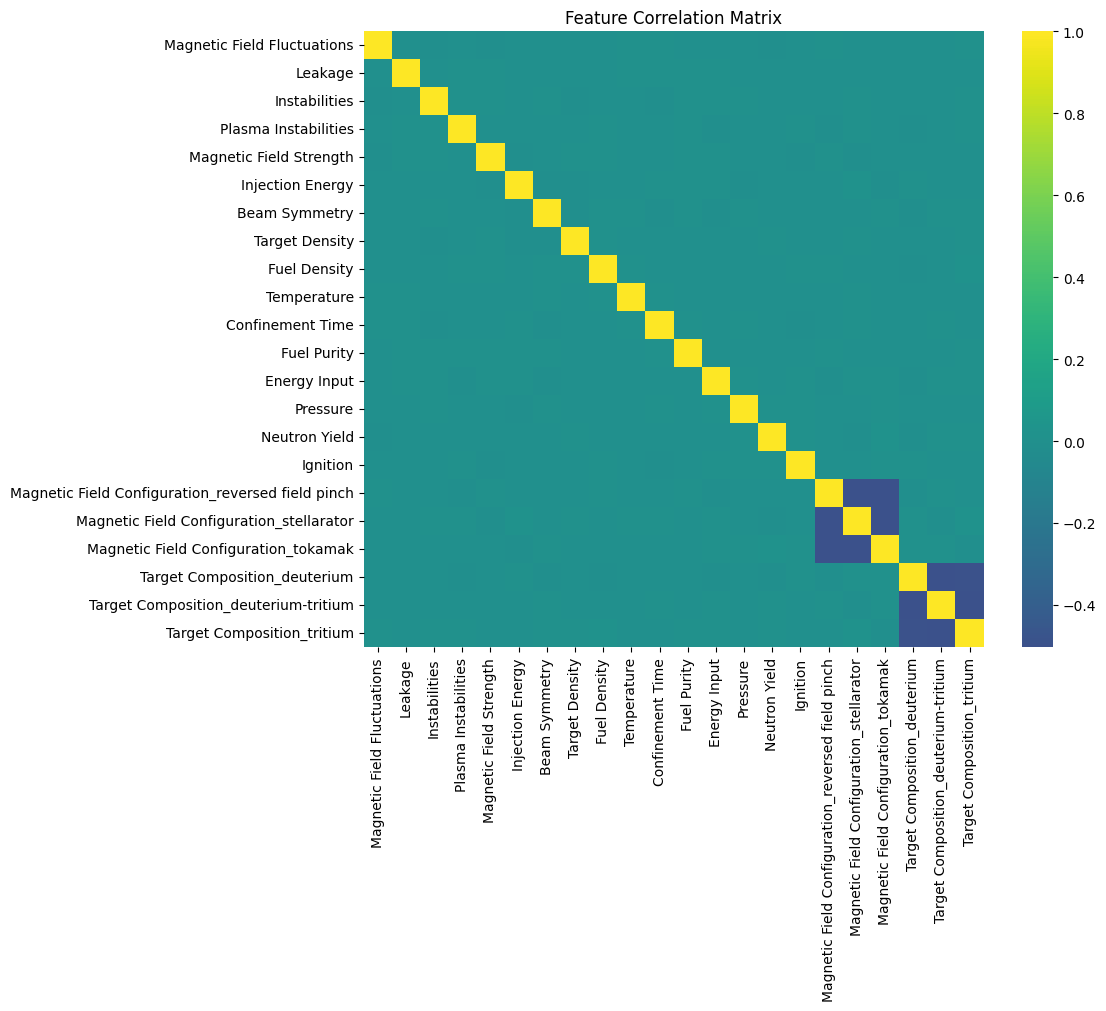

In [ ]:
# =========================
# SECTION 7B: Correlation matrix display (heatmap)
# =========================
# This view can be large; adjust pandas display if needed
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Show the numeric correlation matrix values (head)
print("\nCorrelation matrix preview (top-left block):")
display(corr_mat.iloc[:25, :25])  # show a manageable top-left block

# Optional: plot heatmap if you want a visual (requires seaborn/matplotlib)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, cmap="viridis", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


In [ ]:
# =========================
# SECTION 10: Linear regression via SGD with learning-rate tuning
# =========================
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ensure target is 1D
y_train_vec = np.asarray(y_train).ravel()
y_test_vec  = np.asarray(y_test).ravel()

# SGDRegressor with squared_error loss and NO regularization
sgd = SGDRegressor(
    loss="squared_error",
    penalty=None,              # <-- use None, not "none"
    learning_rate="constant",
    max_iter=2000,
    tol=1e-4,
    random_state=42
)

# Hyperparameter grid for learning rate (eta0)
param_grid = {
    "eta0": [0.2, 0.1, 0.01, 0.001]
}

sgd_search = GridSearchCV(
    estimator=sgd,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

sgd_search.fit(X_train_t, y_train_vec)

print("Best SGD params:", sgd_search.best_params_)
print("Best CV MSE (neg):", float(sgd_search.best_score_))

# Train best model on full training data
sgd_best = sgd_search.best_estimator_
y_pred_train_sgd = sgd_best.predict(X_train_t)
y_pred_test_sgd  = sgd_best.predict(X_test_t)

print("\n[SGD Linear Regression] Train results")
print("MSE:", mean_squared_error(y_train_vec, y_pred_train_sgd))
print("MAE:", mean_absolute_error(y_train_vec, y_pred_train_sgd))
print("R2 :", r2_score(y_train_vec, y_pred_train_sgd))

print("\n[SGD Linear Regression] Test results")
print("MSE:", mean_squared_error(y_test_vec, y_pred_test_sgd))
print("MAE:", mean_absolute_error(y_test_vec, y_pred_test_sgd))
print("R2 :", r2_score(y_test_vec, y_pred_test_sgd))


Best SGD params: {'eta0': 0.001}
Best CV MSE (neg): -842.3276264101902

[SGD Linear Regression] Train results
MSE: 842.784623698921
MAE: 25.103507852809173
R2 : -0.010712367790495891

[SGD Linear Regression] Test results
MSE: 833.9515881522408
MAE: 24.909623954215487
R2 : -0.013278251275792519


In [ ]:
# =========================
# SECTION 11: Regularized linear models (Ridge, Lasso, ElasticNet)
# =========================
from sklearn.linear_model import Ridge, Lasso, ElasticNet

alphas = [0.001, 0.01, 0.1, 1.0, 10.0]

# Ridge
ridge = Ridge(random_state=42)
ridge_search = GridSearchCV(
    estimator=ridge,
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
ridge_search.fit(X_train_t, y_train_vec)
ridge_best = ridge_search.best_estimator_

# Lasso
lasso = Lasso(random_state=42, max_iter=10000)
lasso_search = GridSearchCV(
    estimator=lasso,
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
lasso_search.fit(X_train_t, y_train_vec)
lasso_best = lasso_search.best_estimator_

# ElasticNet
elastic = ElasticNet(random_state=42, max_iter=10000)
elastic_search = GridSearchCV(
    estimator=elastic,
    param_grid={"alpha": alphas, "l1_ratio": [0.2, 0.5, 0.8]},
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
elastic_search.fit(X_train_t, y_train_vec)
elastic_best = elastic_search.best_estimator_

print("Best Ridge params:", ridge_search.best_params_)
print("Best Lasso params:", lasso_search.best_params_)
print("Best ElasticNet params:", elastic_search.best_params_)


Best Ridge params: {'alpha': 10.0}
Best Lasso params: {'alpha': 0.1}
Best ElasticNet params: {'alpha': 0.1, 'l1_ratio': 0.8}


In [ ]:
import numpy as np

lasso_coef = lasso_best.coef_

# Number of zero coefficients
num_zero_lasso = np.sum(lasso_coef == 0)
num_nonzero_lasso = np.sum(lasso_coef != 0)

print("Lasso dropped features:", num_zero_lasso)
print("Lasso kept features:", num_nonzero_lasso)
print("Total features:", len(lasso_coef))


Lasso dropped features: 16
Lasso kept features: 6
Total features: 22


In [ ]:
ridge_coef = ridge_best.coef_

num_zero_ridge = np.sum(ridge_coef == 0)

print("Ridge zero coefficients:", num_zero_ridge)


Ridge zero coefficients: 0


In [ ]:
elastic_coef = elastic_best.coef_

num_zero_elastic = np.sum(elastic_coef == 0)
num_nonzero_elastic = np.sum(elastic_coef != 0)

print("ElasticNet dropped features:", num_zero_elastic)
print("ElasticNet kept features:", num_nonzero_elastic)


ElasticNet dropped features: 15
ElasticNet kept features: 7


In [ ]:
# =========================
# SECTION 12: Train/Test evaluation for Ridge, Lasso, ElasticNet
# =========================
def print_reg_results(name, model, Xtr, ytr, Xte, yte):
    ytr_pred = model.predict(Xtr)
    yte_pred = model.predict(Xte)
    print(f"\n[{name}] Train results")
    print("MSE:", mean_squared_error(ytr, ytr_pred))
    print("MAE:", mean_absolute_error(ytr, ytr_pred))
    print("R2 :", r2_score(ytr, ytr_pred))
    print(f"\n[{name}] Test results")
    print("MSE:", mean_squared_error(yte, yte_pred))
    print("MAE:", mean_absolute_error(yte, yte_pred))
    print("R2 :", r2_score(yte, yte_pred))

print_reg_results("Ridge", ridge_best, X_train_t, y_train_vec, X_test_t, y_test_vec)
print_reg_results("Lasso", lasso_best, X_train_t, y_train_vec, X_test_t, y_test_vec)
print_reg_results("ElasticNet", elastic_best, X_train_t, y_train_vec, X_test_t, y_test_vec)



[Ridge] Train results
MSE: 833.6396992030836
MAE: 25.00701735035333
R2 : 0.000254714463433503

[Ridge] Test results
MSE: 823.1259712003325
MAE: 24.804219743786103
R2 : -0.0001247752588984241

[Lasso] Train results
MSE: 833.7332835873444
MAE: 25.008395381700776
R2 : 0.00014248306771902364

[Lasso] Test results
MSE: 823.0286988639903
MAE: 24.804523493353166
R2 : -6.58621259574943e-06

[ElasticNet] Train results
MSE: 833.7103527841605
MAE: 25.008097762829482
R2 : 0.0001699829125545449

[ElasticNet] Test results
MSE: 823.0306742374445
MAE: 24.80439458444893
R2 : -8.986355466866769e-06


Neural Networks and PINN

In [ ]:
# Neural Networks - with simple hyperparameter tuning (keeps original architecture)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import itertools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# tensors from existing variables (assumes X_train_t, X_test_t, y_train, y_test exist)
X_train_t = torch.tensor(X_train_t, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_t, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# original architecture unchanged
class Net(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x): return self.layers(x)

# prepare numpy arrays for train/val split
X_all = X_train_t.cpu().numpy()
y_all = y_train_t.cpu().numpy().reshape(-1)

# split train -> train/val
X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

def make_loader(X, y, batch_size, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

def train_one(config):
    lr = config["lr"]; wd = config["weight_decay"]; bs = config["batch_size"]; epochs = config["epochs"]
    train_loader = make_loader(X_tr, y_tr, bs, shuffle=True)
    val_loader   = make_loader(X_val, y_val, bs, shuffle=False)

    model = Net(X_tr.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()

    # validation MSE
    model.eval()
    with torch.no_grad():
        Xv = torch.tensor(X_val, dtype=torch.float32).to(device)
        y_pred = model(Xv).cpu().numpy().reshape(-1)
    val_mse = mean_squared_error(y_val, y_pred)
    return val_mse, model

# grid to search (keeps architecture fixed)
grid = {
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-4, 1e-5],
    "batch_size": [32, 64],
    "epochs": [100]
}
keys = list(grid.keys())
combos = [dict(zip(keys, vals)) for vals in itertools.product(*[grid[k] for k in keys])]

results = []
for i, conf in enumerate(combos, 1):
    print(f"Trying {i}/{len(combos)}: {conf}")
    val_mse, _ = train_one(conf)
    print(f"  val MSE = {val_mse:.6f}")
    results.append((val_mse, conf))

results.sort(key=lambda x: x[0])
best_mse, best_conf = results[0]
print("\nBest hyperparameters (by val MSE):")
for k,v in best_conf.items():
    print(f"  {k}: {v}")
print(f"Validation MSE: {best_mse:.6f}")

# retrain best on full train+val and evaluate on test
X_full = np.vstack([X_tr, X_val])
y_full = np.concatenate([y_tr, y_val])
best_bs = best_conf["batch_size"]
full_loader = make_loader(X_full, y_full, best_bs, shuffle=True)

model_best = Net(X_full.shape[1]).to(device)
opt = torch.optim.AdamW(model_best.parameters(), lr=best_conf["lr"], weight_decay=best_conf["weight_decay"])
crit = nn.MSELoss()
for _ in range(best_conf["epochs"]):
    model_best.train()
    for xb, yb in full_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model_best(xb), yb)
        loss.backward()
        opt.step()

model_best.eval()
with torch.no_grad():
    y_pred_train = model_best(X_train_t.to(device)).cpu().numpy()
    y_pred_test  = model_best(X_test_t.to(device)).cpu().numpy()

print("\n[Train]")
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("R2 :", r2_score(y_train, y_pred_train))

print("\n[Test]")
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("R2 :", r2_score(y_test, y_pred_test))


Trying 1/8: {'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'epochs': 100}
  val MSE = 859.255005
Trying 2/8: {'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 64, 'epochs': 100}
  val MSE = 849.348022
Trying 3/8: {'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 32, 'epochs': 100}
  val MSE = 857.555054
Trying 4/8: {'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 64, 'epochs': 100}
  val MSE = 863.888916
Trying 5/8: {'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 32, 'epochs': 100}
  val MSE = 851.797974
Trying 6/8: {'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 64, 'epochs': 100}
  val MSE = 846.635498
Trying 7/8: {'lr': 0.0005, 'weight_decay': 1e-05, 'batch_size': 32, 'epochs': 100}
  val MSE = 859.478638
Trying 8/8: {'lr': 0.0005, 'weight_decay': 1e-05, 'batch_size': 64, 'epochs': 100}
  val MSE = 853.216370

Best hyperparameters (by val MSE):
  lr: 0.0005
  weight_decay: 0.0001
  batch_size: 64
  epochs: 100
Validation MSE: 846.635498

[Train]
MSE: 821.5784

Vishal NN

In [ ]:
# =========================
# SECTION 8: Torch setup
# =========================
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
# =========================
# SECTION 9: Helper — get raw physics inputs aligned with splits
# =========================

REQ_COLS = ["Temperature", "Fuel Density"]
for c in REQ_COLS:
    if c not in X.columns:
        raise ValueError(f"Required physics column '{c}' not found.")

T_train_raw = X_train["Temperature"].to_numpy().reshape(-1, 1)  # K (dataset units look like ~1e8, treat as K)
n_train_raw = X_train["Fuel Density"].to_numpy().reshape(-1, 1) # m^-3 (dataset ~1e19)
T_test_raw  = X_test["Temperature"].to_numpy().reshape(-1, 1)
n_test_raw  = X_test["Fuel Density"].to_numpy().reshape(-1, 1)

# Torch tensors for physics inputs
T_train_t = torch.tensor(T_train_raw, dtype=torch.float32, device=DEVICE)
n_train_t = torch.tensor(n_train_raw, dtype=torch.float32, device=DEVICE)
T_test_t  = torch.tensor(T_test_raw,  dtype=torch.float32, device=DEVICE)
n_test_t  = torch.tensor(n_test_raw,  dtype=torch.float32, device=DEVICE)


In [ ]:
# =========================
# SECTION 10: Torch datasets (for the NN input)
# =========================
X_train_torch = torch.tensor(X_train_t, dtype=torch.float32, device=DEVICE)
y_train_torch = torch.tensor(y_train.to_numpy().reshape(-1, 1), dtype=torch.float32, device=DEVICE)
X_test_torch  = torch.tensor(X_test_t,  dtype=torch.float32, device=DEVICE)
y_test_torch  = torch.tensor(y_test.to_numpy().reshape(-1, 1),  dtype=torch.float32, device=DEVICE)

train_ds = TensorDataset(X_train_torch, y_train_torch, T_train_t, n_train_t)
test_ds  = TensorDataset(X_test_torch,  y_test_torch,  T_test_t,  n_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

/tmp/ipython-input-3977437282.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_torch = torch.tensor(X_train_t, dtype=torch.float32, device=DEVICE)
/tmp/ipython-input-3977437282.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_torch  = torch.tensor(X_test_t,  dtype=torch.float32, device=DEVICE)


In [ ]:
# =========================
# SECTION 11: MLP model
# =========================
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(256,128,64), out_dim=1, dropout=0.1):
        super().__init__()
        layers = []
        last = in_dim
        for h in hidden:
            layers += [nn.Linear(last, h), nn.ReLU(), nn.Dropout(dropout)]
            last = h
        layers += [nn.Linear(last, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


In [ ]:
# =========================
# SECTION 12: φ(T) — fusion reactivity surrogate
# =========================
# We need φ(T) ≈ <σv>(T), a smooth, monotonic-ish function of ion temperature.
# Exact Bosch–Hale fit is long; here we use a simple, differentiable surrogate good enough for PINN regularization.
# Treat temperature in keV internally (dataset looks like ~1e8 K ≈ 8.6 keV).
def phi_T(T_K):
    """
    T_K: torch tensor of Temperature in Kelvin (here ~1e8 K)
    Returns a surrogate for <σv>(T) in arbitrary units (scaled), differentiable.
    """
    # Convert to keV (1 keV ≈ 1.160e7 K)
    T_keV = T_K / 1.160e7
    # Smooth surrogate: ~ T^2 * exp(-b / T^(1/3)) shape, clipped to avoid nan/inf
    eps = 1e-8
    T13 = torch.clamp(T_keV, min=eps).pow(1.0/3.0)
    b = 19.0
    base = torch.clamp(T_keV, min=eps).pow(2.0) * torch.exp(-b / T13)
    # Scale to a reasonable magnitude (so physics loss magnitudes are sane)
    return 1e-22 * base  # arbitrary unit scaling

In [ ]:
# =========================
# SECTION 13: Physics loss (steady-state proxy)
# =========================
class PhysicsLoss(nn.Module):
    """
    Steady-state proxy:
    We want predicted Power ≈ β * n^2 * φ(T)
    -> residual r = y_pred - β * n^2 * φ(T)
    Physics loss = MSE(r, 0)
    β is learned to absorb unknown constants (volume, energy per fusion, etc.).
    """
    def __init__(self, init_log_beta=-30.0):
        super().__init__()
        # β > 0 enforced by softplus
        self.log_beta = nn.Parameter(torch.tensor([init_log_beta], dtype=torch.float32))
        self.softplus = nn.Softplus()

    def forward(self, y_pred, n, T):
        beta = self.softplus(self.log_beta)  # positive
        # n: m^-3 (≈1e19), φ(T): arbitrary units increasing with T
        phys_term = beta * (n**2) * phi_T(T)   # predicted physics-based power (proxy)
        residual  = y_pred - phys_term
        return torch.mean(residual**2), beta.detach()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# =========================
# SECTION 14: Train plain NN (data-only loss)
# =========================
def train_model(model, loader, epochs=60, lr=1e-3):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    for ep in range(1, epochs+1):
        model.train()
        running = 0.0
        for xb, yb, _, _ in loader:
            opt.zero_grad()
            yp = model(xb)
            loss = crit(yp, yb)
            loss.backward()
            opt.step()
            running += loss.item() * xb.size(0)
        if ep % 10 == 0:
            print(f"[NN] Epoch {ep:03d} | train MSE: {running/len(loader.dataset):.4f}")
    return model

def evaluate(model, loader, name="NN"):
    model.eval()
    yhats, ys = [], []
    with torch.no_grad():
        for xb, yb, _, _ in loader:
            yp = model(xb)
            yhats.append(yp.cpu().numpy())
            ys.append(yb.cpu().numpy())
    yhat = np.vstack(yhats).ravel()
    ytrue = np.vstack(ys).ravel()
    mse = mean_squared_error(ytrue, yhat)
    rmse = np.sqrt(mse)
    r2   = r2_score(ytrue, yhat)
    print(f"{name} | RMSE: {rmse:.3f} | R2: {r2:.3f}")
    return yhat, ytrue

nn_model = MLP(in_dim=X_train_t.shape[1])
nn_model = train_model(nn_model, train_loader, epochs=80, lr=1e-3)
_ = evaluate(nn_model, train_loader, "NN (train)")
_ = evaluate(nn_model, test_loader,  "NN (test)")

[NN] Epoch 010 | train MSE: 848.9972
[NN] Epoch 020 | train MSE: 846.2989
[NN] Epoch 030 | train MSE: 843.5119
[NN] Epoch 040 | train MSE: 842.0325
[NN] Epoch 050 | train MSE: 841.0446
[NN] Epoch 060 | train MSE: 840.0813
[NN] Epoch 070 | train MSE: 836.4755
[NN] Epoch 080 | train MSE: 835.4753
NN (train) | RMSE: 28.599 | R2: 0.019
NN (test) | RMSE: 28.829 | R2: -0.010


PINN

In [ ]:
# =========================
# SECTION 8: PINN — model, physics loss, training
# =========================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import math # Added this line

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# --- pull the raw columns we need for physics (from the original, untransformed splits) ---
# We already have: X_train, X_test, y_train, y_test from Section 6
# Make sure the names exist as in CSV:
T_col = "Temperature"      # [K]
n_col = "Fuel Density"     # [m^-3], ~1e20
assert T_col in X_train.columns and n_col in X_train.columns, "Missing physics columns."

# Prepare tensors: transformed features for the NN + raw T, n for physics
Xtr = torch.tensor(X_train_t, dtype=torch.float32)
Xte = torch.tensor(X_test_t,  dtype=torch.float32)
ytr = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
yte = torch.tensor(y_test.values,  dtype=torch.float32).view(-1, 1)

# Raw physical inputs (match row order from the same split!)
Ttr = torch.tensor(X_train[T_col].values, dtype=torch.float32).view(-1, 1)
ntr = torch.tensor(X_train[n_col].values, dtype=torch.float32).view(-1, 1)
Tte = torch.tensor(X_test[T_col].values,  dtype=torch.float32).view(-1, 1)
nte = torch.tensor(X_test[n_col].values,  dtype=torch.float32).view(-1, 1)

class PINNDataset(Dataset):
    def __init__(self, X, y, T, n):
        self.X, self.y, self.T, self.n = X, y, T, n
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.T[i], self.n[i]

train_ds = PINNDataset(Xtr, ytr, Ttr, ntr)
test_ds  = PINNDataset(Xte, yte, Tte, nte)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

# --- simple MLP regressor for Power Output ---
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.GELU(),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# --- steady-state physics: P ≈ β * (n^2) * φ(T) ---
# Use a smooth surrogate for D-T reactivity φ(T) (Bosch–Hale-like bell curve, unitless after scaling).
@torch.no_grad()
def _norm_constants(T, n):
    # scale to keep numbers ~O(1) for stable training
    T_scale = max(1.0, torch.quantile(T, 0.95).item())           # K
    n_scale = max(1.0, torch.quantile(n, 0.95).item())           # m^-3
    y_scale = max(1.0, torch.quantile(ytr, 0.95).item())         # power units
    return T_scale, n_scale, y_scale

T_scale, n_scale, y_scale = _norm_constants(Ttr, ntr)

class Physics:
    def __init__(self, T_scale, n_scale):
        self.T_scale = T_scale
        self.n_scale = n_scale
        # constants for a smooth φ(T) (not exact physics — safe surrogate)
        self.c1 = 1.0          # will be renormalized; keep O(1)
        self.c2 = 4.5          # controls peak location
        self.eps = 1e-7

    def phi(self, T_K):
        """
        Unitless bell-shaped surrogate vs temperature.
        T_K is raw Kelvin. We convert to keV-ish scale implicitly via shape params.
        The exact amplitude is absorbed into β; we only need a *shape*.
        """
        Tn = torch.clamp(T_K / self.T_scale, min=self.eps)  # ~O(1)
        # bell-like: T^2 * exp(-c2/sqrt(T))
        phi = (Tn**2) * torch.exp(-self.c2 / torch.sqrt(Tn + self.eps))
        # normalize to ~[0, 1]
        phi = phi / (phi.max().detach() + self.eps)
        return phi

    def power_law(self, n, T):
        nnorm = torch.clamp(n / self.n_scale, min=0.0)
        return (nnorm**2) * self.phi(T)   # unitless; β will rescale to power units

physics = Physics(T_scale, n_scale)

class PINN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.mlp = MLP(in_dim)
        # β > 0 via softplus; initialize near 1 in scaled units (so outputs ~ y_scale)
        self.beta_raw = nn.Parameter(torch.tensor(0.0))  # softplus(0)=~0.693; we rescale below
        self.softplus = nn.Softplus()
        self.eps = 1e-7

    def beta(self):
        # Map to positive and scale to target magnitude ~ y_scale
        return self.softplus(self.beta_raw) * (y_scale + 1.0)

    def forward(self, X):
        return self.mlp(X)  # predicted power

    def physics_residual(self, n, T, P_pred):
        # residual: P_pred - β * n^2 * φ(T)
        beta = self.beta()
        P_phys = beta * physics.power_law(n, T)
        return P_pred - P_phys

# --- training / evaluation ---
def train_pinn(model, train_loader, test_loader, epochs=150, lr=1e-3, lambda_phys=0.5):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    for ep in range(1, epochs + 1):
        model.train()
        tr_loss = tr_dmse = tr_pmse = 0.0

        for xb, yb, Tb, nb in train_loader:
            xb, yb, Tb, nb = xb.to(device), yb.to(device), Tb.to(device), nb.to(device)
            opt.zero_grad()

            P_pred = model(xb)
            # data loss
            L_data = mse(P_pred, yb)

            # physics loss (residual to zero)
            res = model.physics_residual(nb, Tb, P_pred)
            L_phys = mse(res, torch.zeros_like(res))

            loss = L_data + lambda_phys * L_phys
            loss.backward()
            # gradient clip avoids NaNs
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()

            tr_loss += loss.item() * xb.size(0)
            tr_dmse += L_data.item() * xb.size(0)
            tr_pmse += L_phys.item() * xb.size(0)

        # eval
        model.eval()
        with torch.no_grad():
            def _eval(loader):
                dmse = pmse = 0.0
                for xb, yb, Tb, nb in loader:
                    xb, yb, Tb, nb = xb.to(device), yb.to(device), Tb.to(device), nb.to(device)
                    P_pred = model(xb)
                    dmse += nn.functional.mse_loss(P_pred, yb).item() * xb.size(0)
                    pmse += nn.functional.mse_loss(
                        model.physics_residual(nb, Tb, P_pred),
                        torch.zeros_like(P_pred)
                    ).item() * xb.size(0)
                n = len(loader.dataset)
                return dmse / n, pmse / n

            tr_dmse_epoch, tr_pmse_epoch = tr_dmse / len(train_loader.dataset), tr_pmse / len(train_loader.dataset)
            te_dmse, te_pmse = _eval(test_loader)

        if ep % 10 == 0 or ep == 1:
            print(f"[PINN] Epoch {ep:03d} | "
                  f"train MSE: {tr_dmse_epoch:8.4f} | "
                  f"test MSE: {te_dmse:8.4f} | "
                  f"phys MSE (tr): {tr_pmse_epoch:8.4f} | "
                  f"β={model.beta().detach().cpu().item():.3e}")

    return model

def evaluate_pinn(model, loader, tag=""):
    model.eval()
    with torch.no_grad():
        mse_sum = 0.0
        for xb, yb, Tb, nb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            mse_sum += nn.functional.mse_loss(pred, yb).item() * xb.size(0)
        rmse = math.sqrt(mse_sum/len(loader.dataset))
        print(f"[PINN] {tag} RMSE: {rmse:.4f}")


# ----- run PINN -----
pinn = PINN(in_dim=Xtr.shape[1])
pinn = train_pinn(pinn, train_loader, test_loader, epochs=150, lr=1e-3, lambda_phys=0.5)
evaluate_pinn(pinn, train_loader, tag="train")
evaluate_pinn(pinn, test_loader,  tag="test")
print("Learned β (scaled):", pinn.beta().detach().cpu().item())

/tmp/ipython-input-40234167.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtr = torch.tensor(X_train_t, dtype=torch.float32)
/tmp/ipython-input-40234167.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xte = torch.tensor(X_test_t,  dtype=torch.float32)


[PINN] Epoch 001 | train MSE: 1570.4473 | test MSE: 1043.4353 | phys MSE (tr): 668.9018 | β=7.582e+01
[PINN] Epoch 010 | train MSE: 1035.8988 | test MSE: 1041.1022 | phys MSE (tr): 841.5487 | β=1.309e+02
[PINN] Epoch 020 | train MSE: 1036.1448 | test MSE: 1024.1760 | phys MSE (tr): 833.8923 | β=1.321e+02
[PINN] Epoch 030 | train MSE: 1030.4177 | test MSE: 1049.6340 | phys MSE (tr): 838.3225 | β=1.324e+02
[PINN] Epoch 040 | train MSE: 1027.1416 | test MSE: 1046.1283 | phys MSE (tr): 836.1277 | β=1.330e+02
[PINN] Epoch 050 | train MSE: 1018.4896 | test MSE: 1036.1045 | phys MSE (tr): 842.9503 | β=1.328e+02
[PINN] Epoch 060 | train MSE: 1014.0055 | test MSE: 1020.7086 | phys MSE (tr): 842.1328 | β=1.333e+02
[PINN] Epoch 070 | train MSE: 1008.5369 | test MSE: 1059.0530 | phys MSE (tr): 843.1607 | β=1.323e+02
[PINN] Epoch 080 | train MSE: 1001.8565 | test MSE: 1057.0906 | phys MSE (tr): 847.3368 | β=1.325e+02
[PINN] Epoch 090 | train MSE: 996.2476 | test MSE: 1056.0009 | phys MSE (tr): 850.

In [ ]:
# =========================
# SECTION 8: PINN (fixed & stable)
# =========================
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Pull the columns needed for physics ----
col_T = "Temperature"          # Kelvin in your CSV (~2.5e8 - 4e8)
col_n = "Fuel Density"         # m^-3 in your CSV (~8e19)
assert col_T in X_train.columns and col_n in X_train.columns, "Missing physics columns."

X_phys_train = X_train[[col_n, col_T]].copy()
X_phys_test  = X_test[[col_n, col_T]].copy()

# ---- Normalization for Power (data loss & comparing physics) ----
y_mean = y_train.mean()+
y_std  = y_train.std()
y_train_norm = ((y_train - y_mean) / (y_std + 1e-9)).astype("float32").values.reshape(-1, 1)
y_test_norm  = ((y_test  - y_mean) / (y_std + 1e-9)).astype("float32").values.reshape(-1, 1)

# ---- T and n scaling (keeps physics numerically stable) ----
# Convert T[K] -> T_keV \u2248 T / 1.16045e7; then clamp
def prep_phys_frame(df):
    out = df.copy()
    out["T_keV"] = (out[col_T].values / 1.16045e7).astype("float32")
    out["T_keV"] = np.clip(out["T_keV"].values, 0.05, 200.0)   # safety clamp
    out["n20"]   = (out[col_n].values / 1e20).astype("float32")  # density in 1e20 m^-3 units
    return out[["n20", "T_keV"]].astype("float32").values

Xp_train = prep_phys_frame(X_phys_train)
Xp_test  = prep_phys_frame(X_phys_test)

# ---- Data tensors (we only need Power for data loss, and (n, T) for physics) ----
train_ds = TensorDataset(torch.from_numpy(Xp_train),
                         torch.from_numpy(y_train_norm))
test_ds  = TensorDataset(torch.from_numpy(Xp_test),
                         torch.from_numpy(y_test_norm))

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, drop_last=False)

# ---- Small data network for Power (in normalized units) ----
class DataNet(nn.Module):
    def __init__(self, in_dim=2, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

# ---- Bell-shaped Phi(T): log-normal A * exp( - (logT - Meu)^2 / (2Sigma^2) ) ----

class PhiLogNormal(nn.Module):
    def __init__(self):
        super().__init__()
        # raw parameters; enforce A>0, \u03c3>0 with softplus
        self.raw_A  = nn.Parameter(torch.tensor(0.0))     # starts near 1 after softplus
        self.mu     = nn.Parameter(torch.tensor( np.log(20.0), dtype=torch.float32 ))  # center in log-keV (\u2248 ln 20 keV)
        self.raw_s  = nn.Parameter(torch.tensor(0.7))     # width
        self.softplus = nn.Softplus()

    def forward(self, T_keV):
        # T_keV: (..., 1) positive
        T_keV = torch.clamp(T_keV, 1e-4, 1e4)
        logT  = torch.log(T_keV)
        A  = self.softplus(self.raw_A) + 1e-9
        s  = self.softplus(self.raw_s) + 1e-9
        phi = A * torch.exp(-0.5 * ((logT - self.mu) / s) ** 2)
        # ensure strictly positive & finite
        return torch.nan_to_num(phi, nan=0.0, posinf=0.0, neginf=0.0)

# ---- PINN wrapper ----
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.data_net = DataNet(in_dim=2, hidden=64)
        self.phi = PhiLogNormal()

        # \u03b2 > 0 (use softplus for stability)
        self.raw_beta = nn.Parameter(torch.tensor(-1.0))   # small positive after softplus
        self.softplus = nn.Softplus()

        # Optional scaling to match rough magnitudes (learned)
        self.raw_scale = nn.Parameter(torch.tensor(0.0))   # scale in normalized space
    def beta(self):
        return self.softplus(self.raw_beta) + 1e-9
    def scale(self):
        return torch.exp(self.raw_scale)  # >0

    def physics_power_norm(self, n20, T_keV):
        """
        P_phys (normalized) computed from \u03b2 * n^2 * \u03c6(T)
        - n is in 1e20 m^-3 units -> use n20^2
        - \u03c6(T) bell-shaped in keV
        Then normalize to the same space as y: (P - mean)/std via a learned scale.
        """
        beta = self.beta()
        phiT = self.phi(T_keV)
        P_phys = beta * (n20 ** 2) * phiT   # shape: (B,1)
        # bring physics into roughly similar range; a learned positive scale helps
        P_phys_scaled = self.scale() * P_phys
        # Finally, compare in normalized Power space by mapping with ( / y_std )
        # We only need proportionality; since y was normalized, we keep this in normalized units, too.
        return P_phys_scaled

    def forward(self, Xp):
        # Xp: [n20, T_keV]
        return self.data_net(Xp)  # normalized power prediction

# ---- Training / evaluation helpers ----
def rmse_loss(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2) + 1e-12)

def train_pinn(model, train_loader, test_loader,
               epochs=200, lr=3e-3, lambda_phys=0.3, grad_clip=1.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)

    for ep in range(1, epochs+1):
        model.train()
        tr_loss, tr_data, tr_phys = 0.0, 0.0, 0.0
        for (Xp, yb) in train_loader:
            Xp = Xp.to(device)
            yb = yb.to(device)

            n20  = Xp[:, 0:1]
            TkeV = Xp[:, 1:2]

            y_hat = model(Xp)  # normalized power
            P_phys_norm = model.physics_power_norm(n20, TkeV)

            # data loss (RMSE in normalized space)
            loss_data = rmse_loss(y_hat, yb)

            # physics loss (RMSE between NN prediction and physics in normalized units)
            loss_phys = rmse_loss(y_hat, torch.nan_to_num(P_phys_norm, nan=0.0))

            loss = loss_data + lambda_phys * loss_phys

            opt.zero_grad(set_to_none=True)
            loss.backward()

            # gradient clipping (avoid NaNs in \u03b2 etc.)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            opt.step()

            tr_loss += loss.item() * len(Xp)
            tr_data += loss_data.item() * len(Xp)
            tr_phys += loss_phys.item() * len(Xp)

        # quick eval
        model.eval()
        with torch.no_grad():
            def eval_loader(dl):
                s_data, s_phys, s_all, n = 0, 0, 0, 0
                for (Xp, yb) in dl:
                    Xp, yb = Xp.to(device), yb.to(device)
                    n20  = Xp[:, 0:1]
                    TkeV = Xp[:, 1:2]
                    y_hat = model(Xp)
                    P_phys_norm = model.physics_power_norm(n20, TkeV)
                    ld = rmse_loss(y_hat, yb)
                    lp = rmse_loss(y_hat, torch.nan_to_num(P_phys_norm, nan=0.0))
                    la = ld + lambda_phys * lp
                    s_data += ld.item() * len(Xp)
                    s_phys += lp.item() * len(Xp)
                    s_all  += la.item() * len(Xp)
                    n += len(Xp)
                return s_all/n, s_data/n, s_phys/n

            tr_all, tr_d, tr_p = eval_loader(train_loader)
            te_all, te_d, te_p = eval_loader(test_loader)

        if ep % 10 == 0 or ep == 1:
            print(f"[PINN] Epoch {ep:03d} | "
                  f"train RMSE: {tr_d:.4f} | test RMSE: {te_d:.4f} | "
                  f"phys RMSE (tr): {tr_p:.4f} | \u03b2={model.beta().detach().cpu().item():.3e} | "
                  f"scale={model.scale().detach().cpu().item():.3e}")

    return model

def evaluate_pinn(model, loader, tag=""):
    model.eval()
    with torch.no_grad():
        s, n = 0.0, 0
        for (Xp, yb) in loader:
            Xp, yb = Xp.to(device), yb.to(device)
            y_hat = model(Xp)
            s += rmse_loss(y_hat, yb).item() * len(Xp)
            n += len(Xp)
    print(f"[{tag}] RMSE: {s/n:.4f}")

# ---- Train + report learned \u03b2 and \u03c6(T) center/width ----
pinn = PINN()
pinn = train_pinn(pinn, train_loader, test_loader,
                  epochs=200, lr=3e-3, lambda_phys=0.3, grad_clip=1.0)

evaluate_pinn(pinn, train_loader, "PINN (train)")
evaluate_pinn(pinn, test_loader,  "PINN (test)")

print("Learned \u03b2 (positive):", pinn.beta().detach().cpu().item())
print("Learned \u03c6 params -> A, \u00b5(log-keV), \u03c3:",
      (nn.Softplus()(pinn.phi.raw_A).detach().cpu().item(),
       pinn.phi.mu.detach().cpu().item(),
       nn.Softplus()(pinn.phi.raw_s).detach().cpu().item()))
print("Learned physics scale (to normalized power):",
      pinn.scale().detach().cpu().item())

[PINN] Epoch 001 | train RMSE: 1.0001 | test RMSE: 0.9937 | phys RMSE (tr): 0.0279 | β=2.533e-01 | scale=7.848e-01
[PINN] Epoch 010 | train RMSE: 0.9996 | test RMSE: 0.9933 | phys RMSE (tr): 0.0003 | β=1.117e-01 | scale=3.277e-01
[PINN] Epoch 020 | train RMSE: 0.9996 | test RMSE: 0.9933 | phys RMSE (tr): 0.0003 | β=1.006e-01 | scale=2.854e-01
[PINN] Epoch 030 | train RMSE: 0.9996 | test RMSE: 0.9933 | phys RMSE (tr): 0.0002 | β=1.286e-01 | scale=3.189e-01
[PINN] Epoch 040 | train RMSE: 0.9996 | test RMSE: 0.9933 | phys RMSE (tr): 0.0004 | β=3.133e-01 | scale=5.398e-01
[PINN] Epoch 050 | train RMSE: 0.9996 | test RMSE: 0.9933 | phys RMSE (tr): 0.0006 | β=6.669e-01 | scale=9.512e-01
[PINN] Epoch 060 | train RMSE: 0.9996 | test RMSE: 0.9933 | phys RMSE (tr): 0.0002 | β=6.832e-01 | scale=9.739e-01
[PINN] Epoch 070 | train RMSE: 0.9996 | test RMSE: 0.9933 | phys RMSE (tr): 0.0002 | β=6.847e-01 | scale=9.763e-01
[PINN] Epoch 080 | train RMSE: 0.9996 | test RMSE: 0.9933 | phys RMSE (tr): 0.00

In [ ]:
def evaluate_pinn_original_units(model, X_phys, y_true):
    """
    X_phys : numpy or torch array of shape (N, 2) → [n20, T_keV]
    y_true : original Power Output (not normalized)
    """
    model.eval()
    with torch.no_grad():
        Xp = torch.from_numpy(X_phys).float().to(device)
        y_norm_pred = model(Xp)                     # normalized prediction
        y_pred = y_norm_pred.cpu().numpy() * (y_std + 1e-9) + y_mean  # denormalize

    y_true = y_true.values.reshape(-1, 1)          # make sure shape matches
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    print(f"PINN RMSE in original units: {rmse:.4f}")
    return rmse, y_pred


In [ ]:
pinn_rmse_real, pinn_pred_real = evaluate_pinn_original_units(
    pinn,
    Xp_test,   # the physics-scaled (n20, T_keV) test input
    y_test     # ORIGINAL Power Output (not normalized)
)


PINN RMSE in original units: 28.6887
